# SVM for classification

Load IRIS dataset, check its contents:


In [ ]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [ ]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [ ]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

1.0

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [81]:
import numpy as np

# garder seulement les 2 premières features
X2 = iris.data[:, :2]

# targets
y = iris.target

# enlever la classe 2
mask = (y != 2)
X2 = X2[mask]
y2 = y[mask]

print(X2.shape)
print(np.unique(y2))

(100, 2)
[0 1]


Plot scatterplots of targets 0 and 1 and check the separability of the classes:

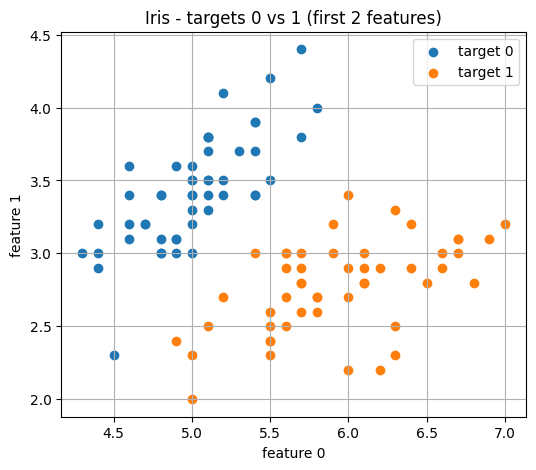

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(X2[y2==0, 0], X2[y2==0, 1], label="target 0")
plt.scatter(X2[y2==1, 0], X2[y2==1, 1], label="target 1")

plt.xlabel("feature 0")
plt.ylabel("feature 1")
plt.title("Iris - targets 0 vs 1 (first 2 features)")
plt.legend()
plt.grid(True)
plt.show()



Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# split
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# tester plusieurs valeurs de C
for C in [1, 10, 200]:
    svm = SVC(kernel="linear", C=C)
    svm.fit(X_train, y_train)
    print("C =", C, "| test accuracy =", svm.score(X_test, y_test))

# garder un modèle final (ex: C=200)
SVMmodel2 = SVC(kernel="linear", C=200)
SVMmodel2.fit(X_train, y_train)
print("Final accuracy:", SVMmodel2.score(X_test, y_test))


C = 1 | test accuracy = 1.0
C = 10 | test accuracy = 1.0
C = 200 | test accuracy = 1.0
Final accuracy: 1.0


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

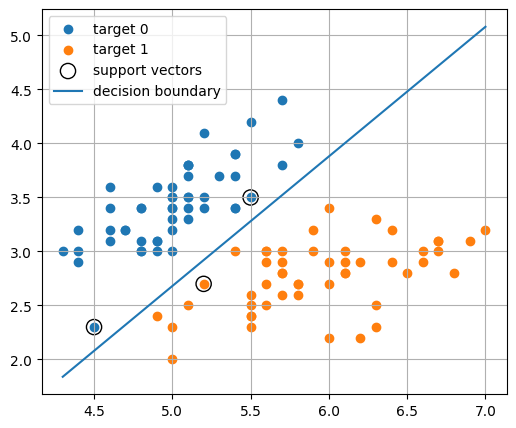

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# Support vectors
supvectors = SVMmodel2.support_vectors_

# plot des points
plt.figure(figsize=(6,5))
plt.scatter(X2[y2==0, 0], X2[y2==0, 1], label="target 0")
plt.scatter(X2[y2==1, 0], X2[y2==1, 1], label="target 1")

# plot support vectors
plt.scatter(supvectors[:,0], supvectors[:,1],
            s=120, facecolors='none', edgecolors='k',
            label="support vectors")

# coefficients de la droite
w = SVMmodel2.coef_[0]
b = SVMmodel2.intercept_[0]

# tracer la droite de décision
x0 = np.linspace(X2[:,0].min(), X2[:,0].max(), 200)
x1 = -(w[0]*x0 + b) / w[1]

plt.plot(x0, x1, label="decision boundary")

plt.legend()
plt.grid(True)
plt.show()


# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

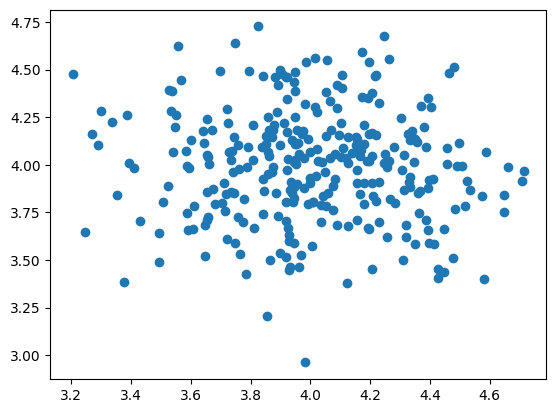

In [89]:
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

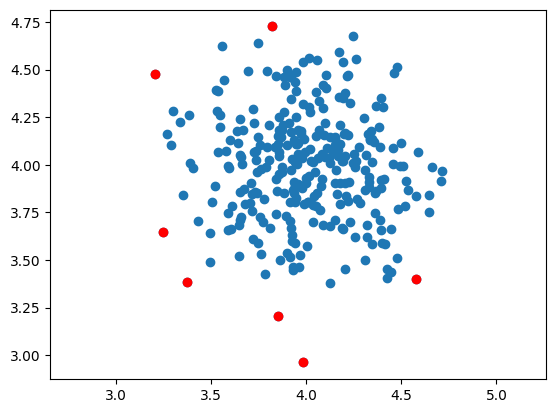

Nb anomalies: 7


In [90]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()

print("Nb anomalies:", len(values))


Plot the support vectors:

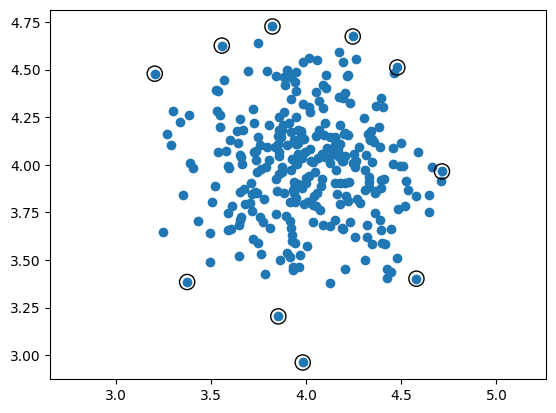

Nb support vectors: 10


In [91]:
sv = SVMmodelOne.support_vectors_

plt.scatter(x[:,0], x[:,1])
plt.scatter(sv[:,0], sv[:,1], facecolors='none', edgecolors='k', s=120)
plt.axis('equal')
plt.show()

print("Nb support vectors:", sv.shape[0])

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.987833799021839


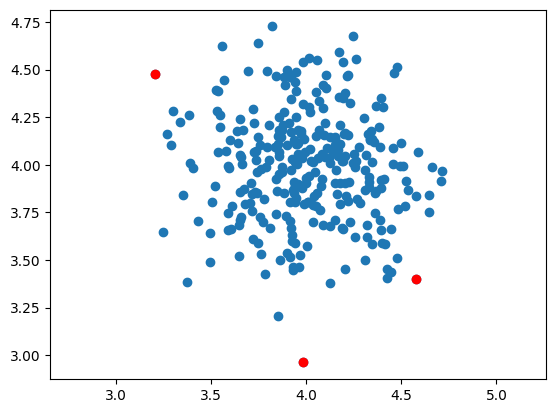

In [93]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.01)
print(thresh)

index = where(scores<=thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()